## SpendWise AI - Notebook 01: Data Preparation

**Objective:** Set up project structure, define spending category taxonomy, generate realistic synthetic transaction data, and prepare train/val/test splits for model training.

**Output:** 100K+ labeled transactions ready for classification.

### 1. Imports & Configuration


In [11]:
# Standard library
import os
import json
import random
from datetime import datetime, timedelta
from pathlib import Path

# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress tracking
from tqdm import tqdm

# PyTorch (for Dataset class)
import torch
from torch.utils.data import Dataset

# Sklearn (for data splitting)
from sklearn.model_selection import train_test_split


# Reproducibility - same random numbers every run
def set_seed(seed: int = 42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)


# Configuration
CONFIG = {
    "seed": 42,
    "n_users": 100,
    "n_months": 6,
    "train_ratio": 0.7,
    "val_ratio": 0.15,
    "test_ratio": 0.15,
}

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

# Hardware check
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.10.0
CUDA Available: False


### 2. Project Directory Setup


In [12]:


# Project root: resolve so files save in this repo (data/, models/), not a wrong folder
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "src" and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists():
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        PROJECT_ROOT = PROJECT_ROOT.parent
        if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "src").exists():
            break


# Directory structure follows ML project best practices
DIRECTORIES = {
    # Raw, unprocessed data
    "data/raw/receipts": "Receipt images for OCR",
    "data/raw/transactions": "Original transaction CSVs",
    "data/raw/categories": "Category taxonomy definitions",
    
    # Cleaned, transformed data
    "data/processed": "Processed datasets ready for training",
    "data/synthetic": "Generated synthetic data",
    
    # Trained model weights
    "models/receipt_model": "Donut OCR model",
    "models/classifier_model": "BERT transaction classifier",
    "models/anomaly_model": "VAE anomaly detector",
    "models/forecaster_model": "Transformer forecaster",
    
    # Reusable Python modules
    "src": "Source code modules",
    
    # Streamlit application
    "app/components": "UI components",
    
    # Configuration files
    "configs": "YAML config files",
}

# Create directories
for dir_path, description in DIRECTORIES.items():
    (PROJECT_ROOT / dir_path).mkdir(parents=True, exist_ok=True)

print("Project structure created:\n")
for dir_path, description in DIRECTORIES.items():
    print(f"  {dir_path:<35} → {description}")


Project structure created:

  data/raw/receipts                   → Receipt images for OCR
  data/raw/transactions               → Original transaction CSVs
  data/raw/categories                 → Category taxonomy definitions
  data/processed                      → Processed datasets ready for training
  data/synthetic                      → Generated synthetic data
  models/receipt_model                → Donut OCR model
  models/classifier_model             → BERT transaction classifier
  models/anomaly_model                → VAE anomaly detector
  models/forecaster_model             → Transformer forecaster
  src                                 → Source code modules
  app/components                      → UI components
  configs                             → YAML config files


### 3. Category Taxonomy Definition


In [13]:
 
# This defines our classification labels. Each category has:
# - **Subcategories**: Finer-grained labels
# - **Keywords**: Help generate realistic merchant names


CATEGORY_TAXONOMY = {
    "Food & Dining": {
        "subcategories": ["Restaurants", "Groceries", "Coffee Shops", "Fast Food", "Food Delivery"],
        "keywords": ["restaurant", "cafe", "starbucks", "mcdonalds", "uber eats", "doordash",
                    "grocery", "safeway", "walmart", "costco", "trader joe", "whole foods",
                    "chipotle", "subway", "pizza", "tim hortons", "dunkin"]
    },
    "Transportation": {
        "subcategories": ["Rideshare", "Gas & Fuel", "Public Transit", "Parking", "Car Maintenance"],
        "keywords": ["uber", "lyft", "gas", "shell", "chevron", "exxon", "transit",
                    "metro", "bus", "parking", "parkade", "autozone", "jiffy lube"]
    },
    "Shopping": {
        "subcategories": ["Amazon", "Clothing", "Electronics", "Department Stores", "Home & Garden"],
        "keywords": ["amazon", "amzn", "walmart", "target", "best buy", "apple",
                    "nike", "zara", "h&m", "nordstrom", "home depot", "ikea"]
    },
    "Bills & Utilities": {
        "subcategories": ["Electricity", "Internet", "Phone", "Water", "Insurance"],
        "keywords": ["hydro", "electric", "pg&e", "comcast", "xfinity", "rogers",
                    "telus", "att", "verizon", "t-mobile", "insurance", "geico"]
    },
    "Subscriptions": {
        "subcategories": ["Streaming", "Software", "Gym", "Cloud Storage", "News"],
        "keywords": ["netflix", "spotify", "apple music", "hulu", "disney", "hbo",
                    "adobe", "microsoft", "dropbox", "gym", "fitness", "nyt"]
    },
    "Entertainment": {
        "subcategories": ["Movies", "Concerts", "Sports", "Games", "Hobbies"],
        "keywords": ["cinema", "amc", "ticketmaster", "stubhub", "concert",
                    "sports", "game", "bowling", "golf", "museum"]
    },
    "Health & Wellness": {
        "subcategories": ["Pharmacy", "Doctor", "Dentist", "Vision", "Fitness"],
        "keywords": ["pharmacy", "cvs", "walgreens", "doctor", "medical",
                    "clinic", "hospital", "dentist", "optometrist"]
    },
    "Travel": {
        "subcategories": ["Flights", "Hotels", "Car Rental", "Vacation"],
        "keywords": ["airline", "united", "delta", "air canada", "westjet",
                    "hotel", "marriott", "hilton", "airbnb", "expedia"]
    },
    "Education": {
        "subcategories": ["Tuition", "Books", "Courses", "Supplies"],
        "keywords": ["university", "college", "tuition", "coursera", "udemy",
                    "textbook", "school", "education"]
    },
    "Personal Care": {
        "subcategories": ["Haircut", "Spa", "Cosmetics"],
        "keywords": ["salon", "haircut", "barber", "spa", "sephora", "ulta"]
    },
    "Financial": {
        "subcategories": ["Bank Fees", "ATM", "Investment", "Loan Payment"],
        "keywords": ["bank fee", "atm", "withdrawal", "transfer", "investment", "loan"]
    },
    "Income": {
        "subcategories": ["Salary", "Freelance", "Refund", "Interest"],
        "keywords": ["payroll", "salary", "direct deposit", "freelance", "refund", "interest"]
    }
}

# Save taxonomy for later use
taxonomy_path = PROJECT_ROOT / "data/raw/categories/taxonomy.json"
with open(taxonomy_path, 'w') as f:
    json.dump(CATEGORY_TAXONOMY, f, indent=2)

# Summary
n_categories = len(CATEGORY_TAXONOMY)
n_subcategories = sum(len(v["subcategories"]) for v in CATEGORY_TAXONOMY.values())

print(f"Category taxonomy defined")
print(f"   Main categories: {n_categories}")
print(f"   Subcategories: {n_subcategories}")
print(f"\nCategories:")
for cat, details in CATEGORY_TAXONOMY.items():
    print(f"   {cat}: {details['subcategories']}")


Category taxonomy defined
   Main categories: 12
   Subcategories: 54

Categories:
   Food & Dining: ['Restaurants', 'Groceries', 'Coffee Shops', 'Fast Food', 'Food Delivery']
   Transportation: ['Rideshare', 'Gas & Fuel', 'Public Transit', 'Parking', 'Car Maintenance']
   Shopping: ['Amazon', 'Clothing', 'Electronics', 'Department Stores', 'Home & Garden']
   Bills & Utilities: ['Electricity', 'Internet', 'Phone', 'Water', 'Insurance']
   Subscriptions: ['Streaming', 'Software', 'Gym', 'Cloud Storage', 'News']
   Entertainment: ['Movies', 'Concerts', 'Sports', 'Games', 'Hobbies']
   Health & Wellness: ['Pharmacy', 'Doctor', 'Dentist', 'Vision', 'Fitness']
   Travel: ['Flights', 'Hotels', 'Car Rental', 'Vacation']
   Education: ['Tuition', 'Books', 'Courses', 'Supplies']
   Personal Care: ['Haircut', 'Spa', 'Cosmetics']
   Financial: ['Bank Fees', 'ATM', 'Investment', 'Loan Payment']
   Income: ['Salary', 'Freelance', 'Refund', 'Interest']


### 4. Merchant Name Generator


In [14]:
 #Real bank transactions show cryptic names like "AMZN MKTP US*MK4H2" not "Amazon".
# This class generates realistic merchant name patterns.

class MerchantNameGenerator:
    """Generate realistic merchant names that mimic bank statement formatting"""
    
    def __init__(self, seed: int = 42):
        self.rng = np.random.default_rng(seed)
        
        # Templates by category and subcategory
        # {name} = random business name, {num} = random number, {code} = alphanumeric code
        self.templates = {
            "Food & Dining": {
                "Restaurants": ["{name} RESTAURANT", "{name} GRILL", "{name} KITCHEN", "REST {name}"],
                "Groceries": ["{name} GROCERY", "{name} MARKET", "GROCERY {name}", "{name} FOODS"],
                "Coffee Shops": ["STARBUCKS #{num}", "TIMS #{num}", "DUNKIN #{num}", "{name} COFFEE"],
                "Fast Food": ["MCDONALD'S #{num}", "SUBWAY #{num}", "CHIPOTLE #{num}", "WENDYS #{num}"],
                "Food Delivery": ["UBER *EATS", "DOORDASH*{name}", "GRUBHUB*{name}", "SKIP*{name}"],
            },
            "Transportation": {
                "Rideshare": ["UBER *TRIP", "LYFT *RIDE", "UBER *{name}"],
                "Gas & Fuel": ["SHELL #{num}", "CHEVRON #{num}", "EXXON #{num}", "BP #{num}"],
                "Public Transit": ["TRANSLINK", "METRO TRANSIT", "{city} TRANSIT", "COMPASS"],
                "Parking": ["IMPARK #{num}", "EASYPARK", "CITY PARKING", "PARKADE {name}"],
                "Car Maintenance": ["AUTOZONE #{num}", "JIFFY LUBE #{num}", "{name} AUTO"],
            },
            "Shopping": {
                "Amazon": ["AMZN MKTP US*{code}", "AMAZON.COM*{code}", "AMZN DIGITAL*{code}"],
                "Clothing": ["ZARA #{num}", "H&M #{num}", "NIKE #{num}", "UNIQLO #{num}"],
                "Electronics": ["BEST BUY #{num}", "APPLE STORE #{num}", "MEMORY EXPRESS"],
                "Department Stores": ["WALMART #{num}", "TARGET #{num}", "COSTCO WHSE #{num}"],
                "Home & Garden": ["HOME DEPOT #{num}", "LOWES #{num}", "IKEA #{num}"],
            },
            "Bills & Utilities": {
                "Electricity": ["BC HYDRO", "PG&E", "{city} ELECTRIC", "HYDRO ONE"],
                "Internet": ["COMCAST *BILL", "XFINITY *BILL", "ROGERS *BILL", "TELUS *BILL"],
                "Phone": ["ATT *BILL", "VERIZON *BILL", "T-MOBILE *BILL", "BELL MOBILITY"],
                "Water": ["{city} WATER", "WATER UTILITY", "AQUA {city}"],
                "Insurance": ["GEICO *POLICY", "STATE FARM", "{name} INSURANCE", "PROGRESSIVE"],
            },
            "Subscriptions": {
                "Streaming": ["NETFLIX.COM", "SPOTIFY", "APPLE.COM/BILL", "DISNEY PLUS", "HBO MAX"],
                "Software": ["ADOBE *CREATIVE", "MICROSOFT *365", "GITHUB INC"],
                "Gym": ["ANYTIME FITNESS", "GOODLIFE FITNESS", "PLANET FITNESS #{num}"],
                "Cloud Storage": ["DROPBOX*{plan}", "ICLOUD *STORAGE", "GOOGLE *STORAGE"],
                "News": ["NYT *DIGITAL", "WSJ *SUBSCRIPTION", "MEDIUM *MEMBER"],
            },
            "Health & Wellness": {
                "Pharmacy": ["CVS/PHARMACY #{num}", "WALGREENS #{num}", "SHOPPERS DRUG"],
                "Doctor": ["DR {name} MD", "{name} MEDICAL", "{city} CLINIC"],
                "Dentist": ["DR {name} DDS", "{name} DENTAL", "{city} DENTISTRY"],
                "Vision": ["{name} OPTOMETRY", "LENSCRAFTERS #{num}", "VISION {city}"],
                "Fitness": ["LULULEMON #{num}", "GNC #{num}", "VITAMIN SHOPPE"],
            },
            "Entertainment": {
                "Movies": ["AMC #{num}", "CINEPLEX #{num}", "REGAL CINEMAS #{num}"],
                "Concerts": ["TICKETMASTER", "STUBHUB *{name}", "EVENTBRITE *{name}"],
                "Sports": ["{city} SPORTS", "DICKS SPORTING #{num}", "SPORT CHEK"],
                "Games": ["STEAM GAMES", "XBOX *GAMES", "PLAYSTATION *{name}"],
                "Hobbies": ["{name} HOBBY", "MICHAELS #{num}", "JOANN FABRIC #{num}"],
            },
            "Travel": {
                "Flights": ["UNITED #{num}", "DELTA #{num}", "AIR CANADA*{code}"],
                "Hotels": ["MARRIOTT #{num}", "HILTON #{num}", "AIRBNB *{code}"],
                "Car Rental": ["ENTERPRISE #{num}", "HERTZ #{num}", "BUDGET RENT"],
                "Vacation": ["EXPEDIA *{code}", "BOOKING.COM*{code}", "TRIPADVISOR"],
            },
            "Income": {
                "Salary": ["PAYROLL", "DIRECT DEPOSIT", "EMPLOYER PAY", "{name} PAYROLL"],
                "Freelance": ["FREELANCE *{name}", "CONTRACT PAY", "GIG PAYMENT"],
                "Refund": ["REFUND *{name}", "CREDIT *{name}", "RETURN *{name}"],
                "Interest": ["INTEREST PAYMENT", "SAVINGS INTEREST", "DIVIDEND"],
            },
        }
        
        # Random business names
        self.names = ["METRO", "URBAN", "CITY", "GOLDEN", "BLUE", "PACIFIC", 
                     "MOUNTAIN", "VALLEY", "MAPLE", "OAK", "CEDAR", "ROYAL"]
        self.cities = ["VANCOUVER", "TORONTO", "SEATTLE", "CALGARY", "MONTREAL"]
    
    def generate(self, category: str, subcategory: str) -> str:
        """Generate a realistic merchant name for given category/subcategory"""
        
        templates = self.templates.get(category, {}).get(subcategory, ["{name} STORE"])
        template = self.rng.choice(templates)
        
        return template.format(
            name=self.rng.choice(self.names),
            num=self.rng.integers(1000, 9999),
            code=f"{self.rng.integers(100000, 999999):06d}",
            city=self.rng.choice(self.cities),
            plan="PLUS" if self.rng.random() > 0.5 else "PRO"
        )

# Test the generator
merchant_gen = MerchantNameGenerator()

print("Sample merchant names:\n")
test_cases = [
    ("Food & Dining", "Coffee Shops"),
    ("Shopping", "Amazon"),
    ("Transportation", "Rideshare"),
    ("Subscriptions", "Streaming"),
]

for cat, subcat in test_cases:
    names = [merchant_gen.generate(cat, subcat) for _ in range(3)]
    print(f"{cat} → {subcat}:")
    for name in names:
        print(f"   • {name}")


Sample merchant names:

Food & Dining → Coffee Shops:
   • STARBUCKS #6890
   • CITY COFFEE
   • DUNKIN #5618
Shopping → Amazon:
   • AMAZON.COM*803409
   • AMAZON.COM*304514
   • AMAZON.COM*349083
Transportation → Rideshare:
   • UBER *BLUE
   • UBER *OAK
   • LYFT *RIDE
Subscriptions → Streaming:
   • DISNEY PLUS
   • DISNEY PLUS
   • APPLE.COM/BILL


### 5. Transaction Generator Class


In [15]:
# Generates complete transaction records with:
# - Realistic amount ranges per category
# - Frequency patterns (coffee: daily, rent: monthly)
# - User spending profiles (some users spend more than others)


class TransactionGenerator:
    """Generate realistic synthetic transaction data"""
    
    def __init__(self, taxonomy: dict, seed: int = 42):
        self.taxonomy = taxonomy
        self.rng = np.random.default_rng(seed)
        self.merchant_gen = MerchantNameGenerator(seed)
        
        # Amount ranges (min, max) in dollars - realistic for each subcategory
        self.amount_ranges = {
            "Restaurants": (15, 120),
            "Groceries": (30, 250),
            "Coffee Shops": (4, 15),
            "Fast Food": (8, 25),
            "Food Delivery": (15, 60),
            "Rideshare": (8, 45),
            "Gas & Fuel": (30, 80),
            "Public Transit": (2.5, 10),
            "Parking": (3, 25),
            "Car Maintenance": (50, 500),
            "Amazon": (10, 200),
            "Clothing": (25, 300),
            "Electronics": (50, 1500),
            "Department Stores": (20, 300),
            "Home & Garden": (30, 500),
            "Electricity": (50, 200),
            "Internet": (50, 120),
            "Phone": (40, 150),
            "Water": (30, 80),
            "Insurance": (100, 400),
            "Streaming": (8, 20),
            "Software": (10, 60),
            "Gym": (25, 80),
            "Cloud Storage": (2, 15),
            "News": (5, 20),
            "Pharmacy": (10, 100),
            "Doctor": (50, 300),
            "Dentist": (100, 500),
            "Vision": (50, 400),
            "Fitness": (20, 100),
            "Movies": (12, 40),
            "Concerts": (50, 300),
            "Sports": (20, 150),
            "Games": (10, 70),
            "Hobbies": (15, 100),
            "Flights": (150, 800),
            "Hotels": (100, 400),
            "Car Rental": (50, 200),
            "Vacation": (200, 1000),
            "Tuition": (500, 5000),
            "Books": (15, 100),
            "Courses": (20, 200),
            "Supplies": (10, 50),
            "Haircut": (20, 80),
            "Spa": (50, 200),
            "Cosmetics": (20, 150),
            "Bank Fees": (5, 35),
            "ATM": (20, 200),
            "Investment": (100, 1000),
            "Loan Payment": (200, 1500),
            "Salary": (2000, 8000),
            "Freelance": (100, 2000),
            "Refund": (10, 200),
            "Interest": (1, 50),
        }
        
        # Monthly frequency (min, max transactions per month)
        self.frequency = {
            "Restaurants": (3, 10),
            "Groceries": (4, 8),
            "Coffee Shops": (8, 20),
            "Fast Food": (2, 8),
            "Food Delivery": (2, 8),
            "Rideshare": (4, 15),
            "Gas & Fuel": (2, 5),
            "Public Transit": (10, 40),
            "Parking": (2, 8),
            "Car Maintenance": (0, 1),
            "Amazon": (2, 8),
            "Clothing": (1, 4),
            "Electronics": (0, 2),
            "Department Stores": (1, 4),
            "Home & Garden": (0, 2),
            "Streaming": (1, 1),  # Fixed monthly subscriptions
            "Software": (1, 1),
            "Gym": (1, 1),
            "Pharmacy": (1, 3),
            "Movies": (1, 3),
            "Salary": (2, 2),  # Bi-weekly paychecks
        }
    
    def _generate_amount(self, subcategory: str) -> float:
        """Generate realistic transaction amount"""
        min_amt, max_amt = self.amount_ranges.get(subcategory, (10, 100))
        amount = self.rng.uniform(min_amt, max_amt)
        
        # Round to realistic values (no one pays $23.7834)
        if amount < 20:
            return round(amount, 2)
        elif amount < 100:
            return round(amount * 2) / 2  # Round to nearest 0.50
        else:
            return round(amount)
    
    def _generate_date(self, start: datetime, end: datetime) -> datetime:
        """Generate random transaction date with realistic time"""
        days = (end - start).days
        random_day = self.rng.integers(0, max(days, 1))
        
        # Realistic transaction times (6 AM - 11 PM)
        hour = self.rng.integers(6, 23)
        minute = self.rng.integers(0, 59)
        
        return start + timedelta(days=int(random_day), hours=int(hour), minutes=int(minute))
    
    def generate(self, n_users: int = 100, n_months: int = 6) -> pd.DataFrame:
        """Generate complete transaction dataset"""
        
        transactions = []
        end_date = datetime.now()
        start_date = end_date - timedelta(days=n_months * 30)
        
        for user_id in tqdm(range(n_users), desc="Generating transactions"):
            # Each user has a spending multiplier (some spend more than others)
            spending_profile = self.rng.uniform(0.5, 2.0)
            
            for category, details in self.taxonomy.items():
                for subcategory in details["subcategories"]:
                    
                    # Get monthly frequency for this subcategory
                    freq_min, freq_max = self.frequency.get(subcategory, (1, 3))
                    base_monthly_freq = self.rng.integers(freq_min, freq_max + 1)
                    
                    # Generate transactions for each month
                    for month in range(n_months):
                        month_start = start_date + timedelta(days=month * 30)
                        month_end = month_start + timedelta(days=30)
                        
                        # Number of transactions this month (Poisson for natural variation)
                        n_txns = self.rng.poisson(base_monthly_freq * spending_profile)
                        
                        for _ in range(max(0, n_txns)):
                            amount = self._generate_amount(subcategory)
                            
                            # Income is positive, expenses are negative
                            if category == "Income":
                                amount = abs(amount)
                            else:
                                amount = -abs(amount)
                            
                            transactions.append({
                                "user_id": f"user_{user_id:04d}",
                                "transaction_id": f"txn_{len(transactions):08d}",
                                "date": self._generate_date(month_start, month_end),
                                "merchant": self.merchant_gen.generate(category, subcategory),
                                "amount": amount,
                                "category": category,
                                "subcategory": subcategory,
                            })
        
        # Convert to DataFrame and sort
        df = pd.DataFrame(transactions)
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values(["user_id", "date"]).reset_index(drop=True)
        
        return df


### 6. Generate Dataset


In [16]:
#Generate synthetic transactions
generator = TransactionGenerator(CATEGORY_TAXONOMY, seed=CONFIG["seed"])
transactions_df = generator.generate(
    n_users=CONFIG["n_users"],
    n_months=CONFIG["n_months"]
)

# Quick overview
print("Dataset generated!\n")
print(f"Total transactions: {len(transactions_df):,}")
print(f"Unique users: {transactions_df['user_id'].nunique()}")
print(f"Date range: {transactions_df['date'].min().date()} → {transactions_df['date'].max().date()}")
print(f"Categories: {transactions_df['category'].nunique()}")
print(f"Subcategories: {transactions_df['subcategory'].nunique()}")

# Sample transactions
print("\nSample transactions:")
print(transactions_df[["date", "merchant", "amount", "category", "subcategory"]].head(10).to_string())


Generating transactions: 100%|██████████| 100/100 [00:02<00:00, 44.52it/s]


Dataset generated!

Total transactions: 122,754
Unique users: 100
Date range: 2025-09-15 → 2026-03-13
Categories: 12
Subcategories: 54

Sample transactions:
                        date           merchant  amount           category        subcategory
0 2025-09-15 01:47:04.612632       DUNKIN #4678   -4.40      Food & Dining       Coffee Shops
1 2025-09-15 03:28:04.612632    LULULEMON #1235  -60.00  Health & Wellness            Fitness
2 2025-09-15 04:19:04.612632       WENDYS #3560  -12.73      Food & Dining          Fast Food
3 2025-09-15 04:19:04.612632  AMAZON.COM*606716 -117.00           Shopping             Amazon
4 2025-09-15 05:10:04.612632           BC HYDRO  -95.00  Bills & Utilities        Electricity
5 2025-09-15 05:38:04.612632       GOLDEN STORE -982.00          Education            Tuition
6 2025-09-15 07:07:04.612632       TARGET #3196 -163.00           Shopping  Department Stores
7 2025-09-15 13:04:04.612632   MCDONALD'S #5079  -24.00      Food & Dining          Fast Fo

### 7. Exploratory Data Analysis


Expense Statistics:
   Mean: $129.44
   Median: $39.00
   Min: $2.00
   Max: $4996.00


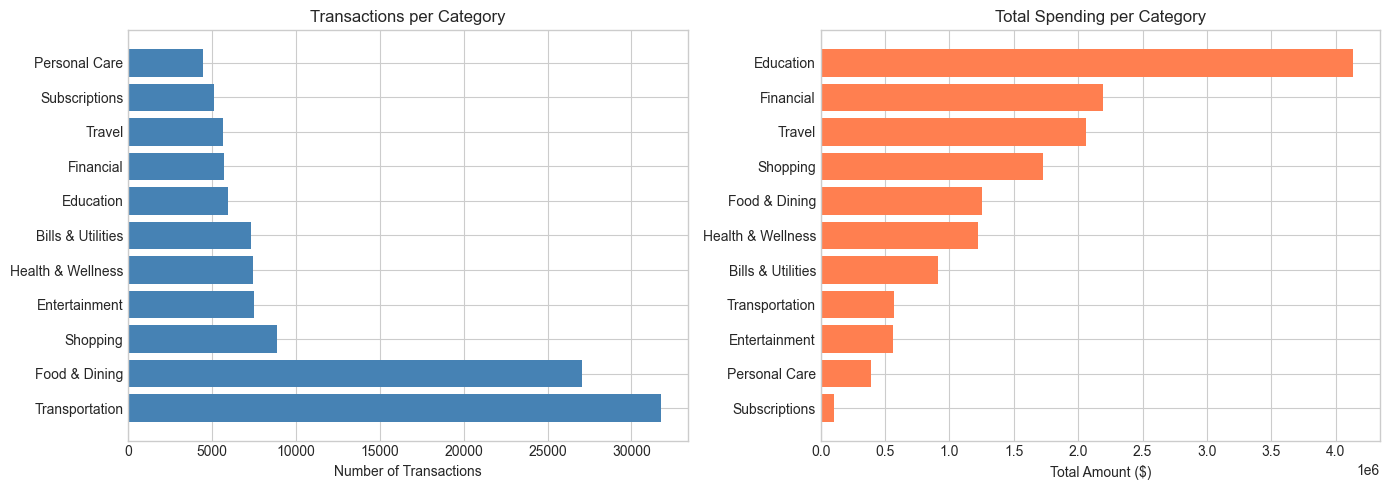

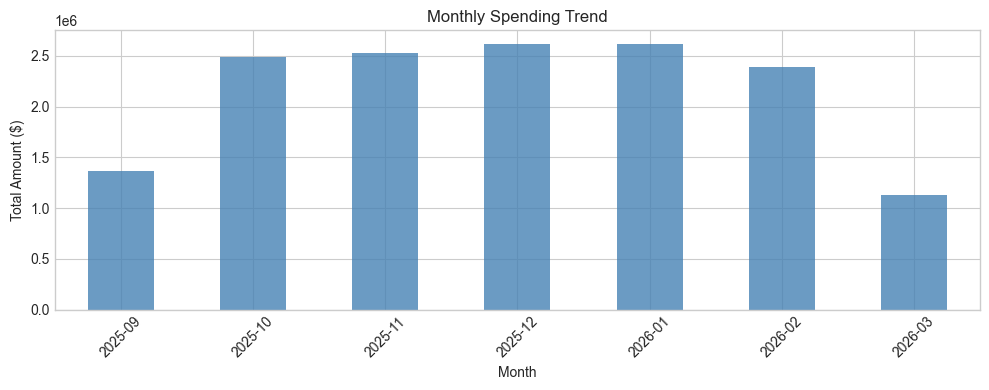

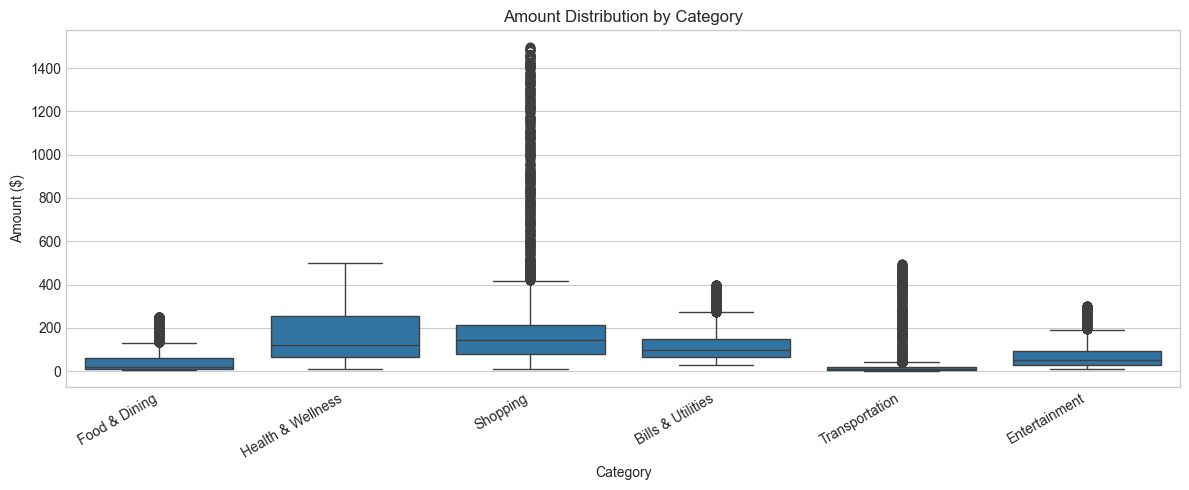

In [17]:
#Always visualize data before training to catch:
# - Class imbalance
# - Unexpected distributions
# - Data quality issues

# Expenses only (negative amounts)
expenses_df = transactions_df[transactions_df["amount"] < 0].copy()
expenses_df["amount"] = expenses_df["amount"].abs()

print("Expense Statistics:")
print(f"   Mean: ${expenses_df['amount'].mean():.2f}")
print(f"   Median: ${expenses_df['amount'].median():.2f}")
print(f"   Min: ${expenses_df['amount'].min():.2f}")
print(f"   Max: ${expenses_df['amount'].max():.2f}")

# Category distribution - transactions count vs total amount
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count per category
cat_counts = expenses_df["category"].value_counts()
axes[0].barh(cat_counts.index, cat_counts.values, color="steelblue")
axes[0].set_xlabel("Number of Transactions")
axes[0].set_title("Transactions per Category")

# Total amount per category  
cat_amounts = expenses_df.groupby("category")["amount"].sum().sort_values()
axes[1].barh(cat_amounts.index, cat_amounts.values, color="coral")
axes[1].set_xlabel("Total Amount ($)")
axes[1].set_title("Total Spending per Category")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/processed/eda_category_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Monthly spending trend
expenses_df["month"] = expenses_df["date"].dt.to_period("M")
monthly = expenses_df.groupby("month")["amount"].sum()

plt.figure(figsize=(10, 4))
monthly.plot(kind="bar", color="steelblue", alpha=0.8)
plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Amount ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/processed/eda_monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()

# Amount distribution by category (box plot)
plt.figure(figsize=(12, 5))
top_categories = expenses_df["category"].value_counts().head(6).index
plot_df = expenses_df[expenses_df["category"].isin(top_categories)]

sns.boxplot(data=plot_df, x="category", y="amount")
plt.title("Amount Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Amount ($)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/processed/eda_amount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 8. Prepare Classifier Dataset & Split


In [18]:
# - Create text input: "MERCHANT_NAME $AMOUNT"
# - Encode labels as integers (required for PyTorch)
# - Stratified split: maintains class proportions in train/val/test


def prepare_classifier_data(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """
    Prepare data for transaction classifier
    
    Returns:
        df: DataFrame with text input and encoded labels
        mappings: Dictionary for converting between labels and IDs
    """
    
    # Create text input (what the model sees)
    clf_df = df.copy()
    clf_df["text"] = clf_df.apply(
        lambda x: f"{x['merchant']} ${abs(x['amount']):.2f}", 
        axis=1
    )
    
    # Encode labels as integers
    categories = sorted(df["category"].unique())
    subcategories = sorted(df["subcategory"].unique())
    
    cat_to_id = {cat: i for i, cat in enumerate(categories)}
    subcat_to_id = {subcat: i for i, subcat in enumerate(subcategories)}
    
    clf_df["category_id"] = clf_df["category"].map(cat_to_id)
    clf_df["subcategory_id"] = clf_df["subcategory"].map(subcat_to_id)
    
    # Create mapping dictionaries (for inference later)
    mappings = {
        "category_to_id": cat_to_id,
        "id_to_category": {str(v): k for k, v in cat_to_id.items()},
        "subcategory_to_id": subcat_to_id,
        "id_to_subcategory": {str(v): k for k, v in subcat_to_id.items()},
    }
    
    return clf_df, mappings

# Prepare classifier dataset
clf_df, label_mappings = prepare_classifier_data(transactions_df)

print("Classifier data prepared")
print(f"\nLabel mappings:")
print(f"   Categories: {len(label_mappings['category_to_id'])}")
print(f"   Subcategories: {len(label_mappings['subcategory_to_id'])}")

print(f"\nSample text inputs:")
for _, row in clf_df.sample(5, random_state=42).iterrows():
    print(f"   '{row['text']}' → {row['category']}")

# Train / Validation / Test split (stratified by category)
train_df, temp_df = train_test_split(
    clf_df,
    test_size=(CONFIG["val_ratio"] + CONFIG["test_ratio"]),
    stratify=clf_df["category"],
    random_state=CONFIG["seed"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=CONFIG["test_ratio"] / (CONFIG["val_ratio"] + CONFIG["test_ratio"]),
    stratify=temp_df["category"],
    random_state=CONFIG["seed"]
)

print(f"\nDataset splits:")
print(f"   Train: {len(train_df):,} ({len(train_df)/len(clf_df)*100:.1f}%)")
print(f"   Val:   {len(val_df):,} ({len(val_df)/len(clf_df)*100:.1f}%)")
print(f"   Test:  {len(test_df):,} ({len(test_df)/len(clf_df)*100:.1f}%)")

# Verify stratification (category proportions should be similar)
print("\nCategory distribution check (should be similar across splits):")
print(f"\n{'Category':<20} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 50)

for cat in sorted(clf_df["category"].unique())[:5]:  # Show first 5
    train_pct = (train_df["category"] == cat).mean() * 100
    val_pct = (val_df["category"] == cat).mean() * 100
    test_pct = (test_df["category"] == cat).mean() * 100
    print(f"{cat:<20} {train_pct:>7.1f}% {val_pct:>7.1f}% {test_pct:>7.1f}%")


Classifier data prepared

Label mappings:
   Categories: 12
   Subcategories: 54

Sample text inputs:
   'UBER *TRIP $32.50' → Transportation
   'BELL MOBILITY $76.00' → Bills & Utilities
   'BP #7993 $56.00' → Transportation
   'TIMS #1248 $14.26' → Food & Dining
   'MOUNTAIN COFFEE $12.77' → Food & Dining

Dataset splits:
   Train: 85,927 (70.0%)
   Val:   18,413 (15.0%)
   Test:  18,414 (15.0%)

Category distribution check (should be similar across splits):

Category                Train      Val     Test
--------------------------------------------------
Bills & Utilities        6.0%     6.0%     6.0%
Education                4.9%     4.9%     4.9%
Entertainment            6.1%     6.1%     6.1%
Financial                4.7%     4.7%     4.7%
Food & Dining           22.0%    22.0%    22.0%


### 9. PyTorch Dataset Class


In [19]:
#PyTorch requires data in a specific format:
# - **Tokenization**: Convert text → numbers that BERT understands
# - **Tensors**: PyTorch's array format (like NumPy but GPU-compatible)
# - **Dataset class**: Enables batching, shuffling, parallel loading

# Disable Hugging Face download progress (avoids widget output that some viewers can't render)
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

class TransactionDataset(Dataset):
    """
    PyTorch Dataset for transaction classification
    
    Converts raw text + labels into tokenized tensors for BERT
    """
    
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 64):
        """
        Args:
            df: DataFrame with 'text', 'category_id', 'subcategory_id' columns
            tokenizer: HuggingFace tokenizer (e.g., DistilBERT)
            max_length: Maximum sequence length (64 is enough for short transaction texts)
        """
        self.texts = df["text"].tolist()
        self.category_labels = df["category_id"].astype(int).tolist()
        self.subcategory_labels = df["subcategory_id"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self) -> int:
        """Required: Return dataset size"""
        return len(self.texts)
    
    def __getitem__(self, idx: int) -> dict:
        """
        Required: Return one sample as dictionary of tensors
        
        This is called by DataLoader to fetch individual samples
        """
        text = str(self.texts[idx])
        
        # Tokenize: text → token IDs + attention mask
        encoding = self.tokenizer(
            text,
            truncation=True,      # Cut if too long
            padding="max_length", # Pad if too short
            max_length=self.max_length,
            return_tensors="pt"   # Return PyTorch tensors
        )
        
        return {
            "input_ids": encoding["input_ids"].squeeze(0),       # Token IDs
            "attention_mask": encoding["attention_mask"].squeeze(0),  # 1=real, 0=padding
            "category_label": torch.tensor(self.category_labels[idx], dtype=torch.long),
            "subcategory_label": torch.tensor(self.subcategory_labels[idx], dtype=torch.long),
        }

# Test the Dataset class
try:
    from transformers import AutoTokenizer
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers"])
    from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
test_dataset = TransactionDataset(train_df.head(100), tokenizer)

# Get one sample
sample = test_dataset[0]

print("Dataset class works!")
print(f"\nSample output:")
print(f"   input_ids shape: {sample['input_ids'].shape}")  # [64] - token IDs
print(f"   attention_mask shape: {sample['attention_mask'].shape}")  # [64] - which tokens are real
print(f"   category_label: {sample['category_label'].item()}")
print(f"   subcategory_label: {sample['subcategory_label'].item()}")

# Decode back to text to verify
decoded = tokenizer.decode(sample["input_ids"], skip_special_tokens=True)
print(f"\n   Original: {test_dataset.texts[0]}")
print(f"   Decoded:  {decoded}")


Dataset class works!

Sample output:
   input_ids shape: torch.Size([64])
   attention_mask shape: torch.Size([64])
   category_label: 1
   subcategory_label: 50

   Original: VALLEY STORE $2564.00
   Decoded:  valley store $ 2564. 00


### 10. Save Outputs


In [20]:
#Save all datasets
transactions_df.to_csv(PROJECT_ROOT / "data/synthetic/transactions_full.csv", index=False)
train_df.to_csv(PROJECT_ROOT / "data/processed/train.csv", index=False)
val_df.to_csv(PROJECT_ROOT / "data/processed/val.csv", index=False)
test_df.to_csv(PROJECT_ROOT / "data/processed/test.csv", index=False)

# Save label mappings
with open(PROJECT_ROOT / "data/processed/label_mappings.json", "w") as f:
    json.dump(label_mappings, f, indent=2)

# Save config
with open(PROJECT_ROOT / "configs/data_config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

print("All files saved:\n")
print(f"   data/synthetic/transactions_full.csv  ({len(transactions_df):,} rows)")
print(f"   data/processed/train.csv              ({len(train_df):,} rows)")
print(f"   data/processed/val.csv                ({len(val_df):,} rows)")
print(f"   data/processed/test.csv               ({len(test_df):,} rows)")
print(f"   data/processed/label_mappings.json")
print(f"   data/raw/categories/taxonomy.json")
print(f"   configs/data_config.json")


All files saved:

   data/synthetic/transactions_full.csv  (122,754 rows)
   data/processed/train.csv              (85,927 rows)
   data/processed/val.csv                (18,413 rows)
   data/processed/test.csv               (18,414 rows)
   data/processed/label_mappings.json
   data/raw/categories/taxonomy.json
   configs/data_config.json
